In [ ]:
# 한글이 깨지지 않게 — 폰트를 설치하고 matplotlib 에 바로 등록한다.
# fc-cache 만으로는 안 된다. matplotlib 이 import 시점에 만들어 둔 폰트 목록은
# 디스크 캐시를 지워도 그대로라, addfont 로 살아 있는 목록에 직접 꽂아야 한다.
!apt-get install -y -qq fonts-nanum fonts-noto-cjk > /dev/null

import os, glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

for d in ["/usr/share/fonts/truetype/nanum",
          "/usr/share/fonts/opentype/noto",
          "/usr/share/fonts/noto"]:
    if os.path.isdir(d):
        for f in glob.glob(os.path.join(d, "**", "*.tt[fc]"), recursive=True) + \
                 glob.glob(os.path.join(d, "**", "*.otf"), recursive=True):
            try:
                fm.fontManager.addfont(f)
            except Exception:
                pass          # 못 읽는 파일은 건너뛴다

have = {f.name for f in fm.fontManager.ttflist}
name = next((n for n in ["NanumBarunGothic", "NanumGothic",
                         "Noto Sans CJK KR", "Noto Sans KR", "NanumMyeongjo"]
             if n in have), None)
if name is None:
    raise RuntimeError("한글 폰트를 못 찾았다 — 설치가 실패했을 수 있다.")

mpl.rcParams["font.family"] = name
mpl.rcParams["axes.unicode_minus"] = False   # 마이너스가 네모로 나오는 것 방지
print("한글 폰트:", name)

In [ ]:
# ① 기본 — 표준 라이브러리와 pandas·numpy·matplotlib
import pandas as pd
import numpy as np
import os, re
from glob import glob
import time
import matplotlib as mpl
import matplotlib.pyplot as plt


In [ ]:
# ② 분석·모델링 — Colab 에 기본으로 있는 것들
from tqdm import tqdm


# **https://bigvalue.ai**

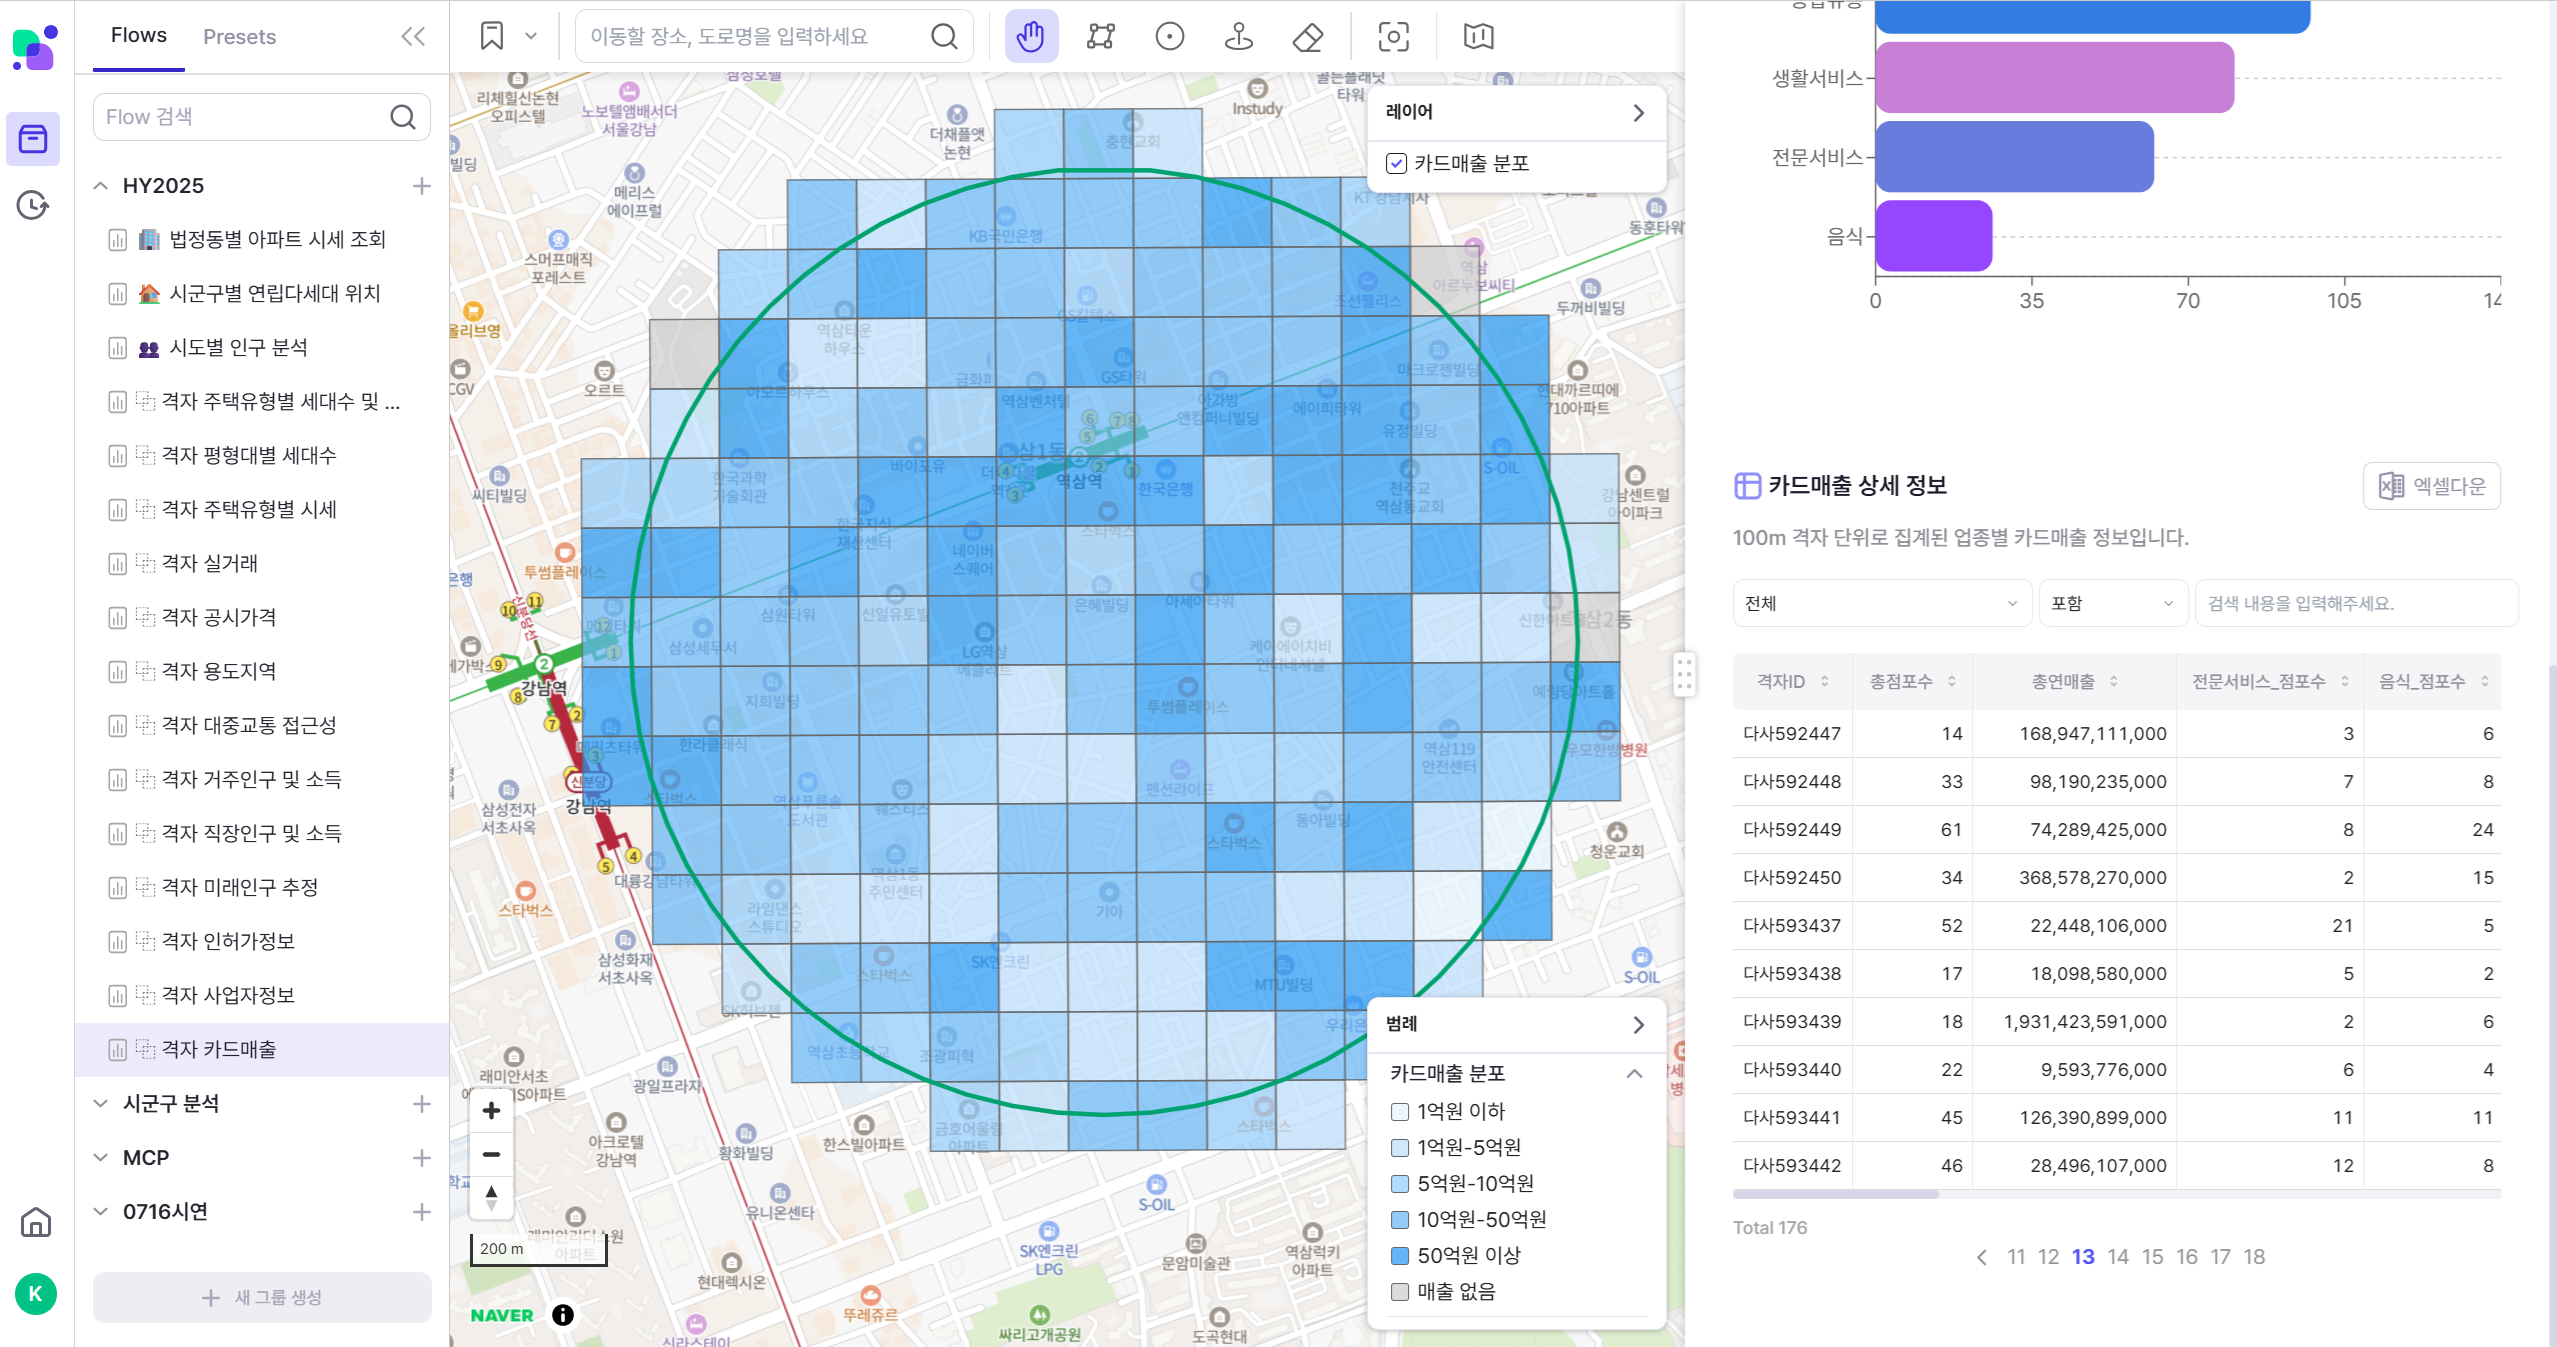

In [ ]:
# #데이터 다운로드
!wget -q "https://github.com/kloud80/urban_datamining_26/releases/download/data/w04_house.xlsx" -O "house.xlsx"
!wget -q "https://github.com/kloud80/urban_datamining_26/releases/download/data/w04_job.xlsx" -O "job.xlsx"
!wget -q "https://github.com/kloud80/urban_datamining_26/releases/download/data/w04_sales.xlsx" -O "sales.xlsx"


In [ ]:
house_data = pd.read_excel('house.xlsx')
job_data = pd.read_excel('job.xlsx')
sales_data = pd.read_excel('sales.xlsx')

data = pd.merge(sales_data, house_data, on='격자ID')
data = pd.merge(data, job_data, on='격자ID')

cols = ['총연매출','전문서비스_평균연매출', '음식_평균연매출', '일반유통_평균연매출',
      '생활서비스_평균연매출', '문화레져_평균연매출', '종합유통_평균연매출', '전체_평균연매출']

for col in cols :
  data[col] = data[col].apply(lambda x : int(x.replace(',', '')))

data[['총연매출','전문서비스_평균연매출', '음식_평균연매출', '일반유통_평균연매출',
      '생활서비스_평균연매출', '문화레져_평균연매출', '종합유통_평균연매출', '전체_평균연매출']].dtypes

data['종속'] = data['총연매출'].apply(lambda x : 1 if x > 40000000000 else 0)

data.head(10)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define independent and dependent variables
y_label = '종속'
X_labels = ['총인구수', '남성인구', '여성인구', '거주인구추정소득(백만원)', '0-4세', '5-9세', '10-14세', '15-19세', '20-24세', '25-29세', '30-34세', '35-39세', '40-44세', '45-49세', '50-54세', '55-59세', '60-64세', '65-69세', '70-74세', '75-79세', '80-84세', '85-89세', '90-94세', '95-99세', '100세이상', '총직장인구수', '직장인구추정소득(백만원)', '농업·임업·어업', '광업', '제조업', '전기·가스·증기·수도업', '하수·폐기·재생·복원업', '건설업', '도매·소매업', '운수업', '숙박·음식업', '출판·영상·통신·서비스업', '금융·보험업', '부동산·임대업', '전문·과학·기술서비스업', '시설관리·지원서비스업', '공공·국방·사회보장업', '교육서비스업', '보건·사회복지서비스업', '예술·스포츠·여가관련업', '협회·단체·수리·기타업', '국제·외국기관', '기타']

# Create numpy arrays
X = data[X_labels].fillna(0).values
y = data[y_label].values.reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

In [ ]:
# prompt:  keras를 이용해 denselayer를 구성, 인풋 110개, 인풋노드 노멀라이징하고, 하든레이어가 5개층 각각 220, 440, 220, 110, 20개의 히든노드로 구성, 아웃풋 1개(0 or 1) 학습하는 코드 생성,

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization

model = keras.Sequential([
    layers.Dense(220, activation='relu', input_shape=(X.shape[1],)),
    BatchNormalization(),  # Input layer normalization
    layers.Dense(440, activation='relu'),
    layers.Dense(220, activation='relu'),
    layers.Dense(110, activation='relu'),
    layers.Dense(20, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


In [ ]:
# prompt: 위 학습 코드에서 실행 시간 출력하기

import time

start_time = time.time()

# Your training code here
history = model.fit(X, y, epochs=300)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Training time: {elapsed_time:.2f} seconds")


plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()


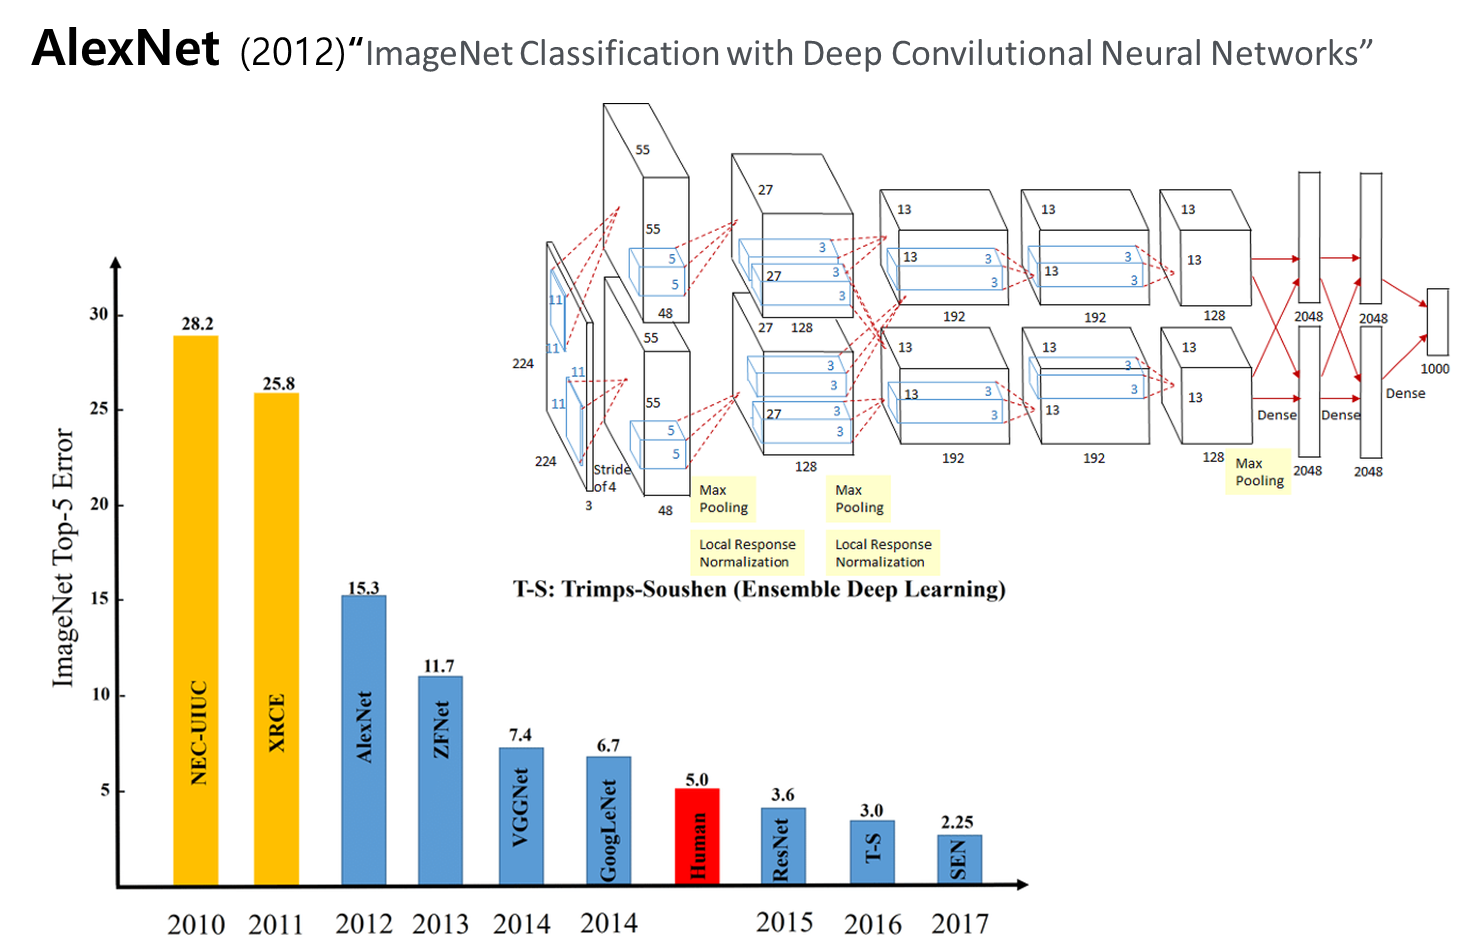

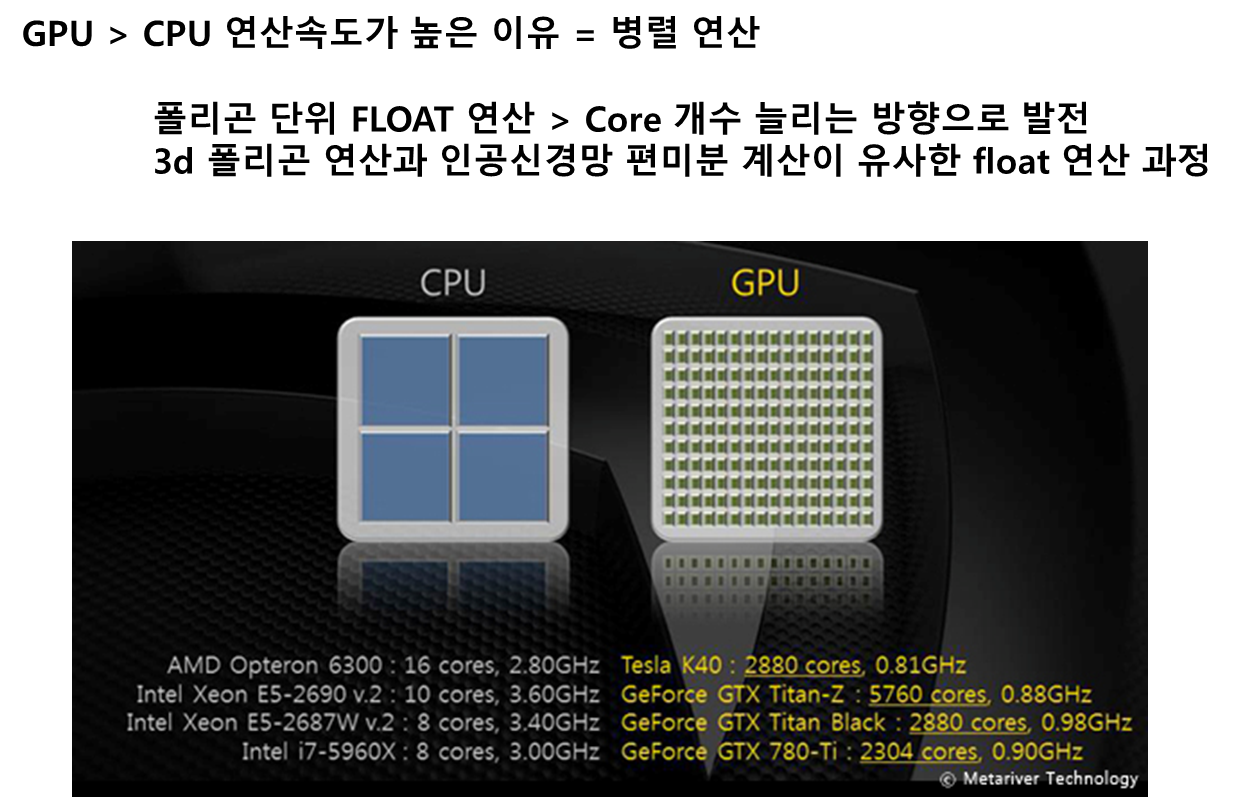

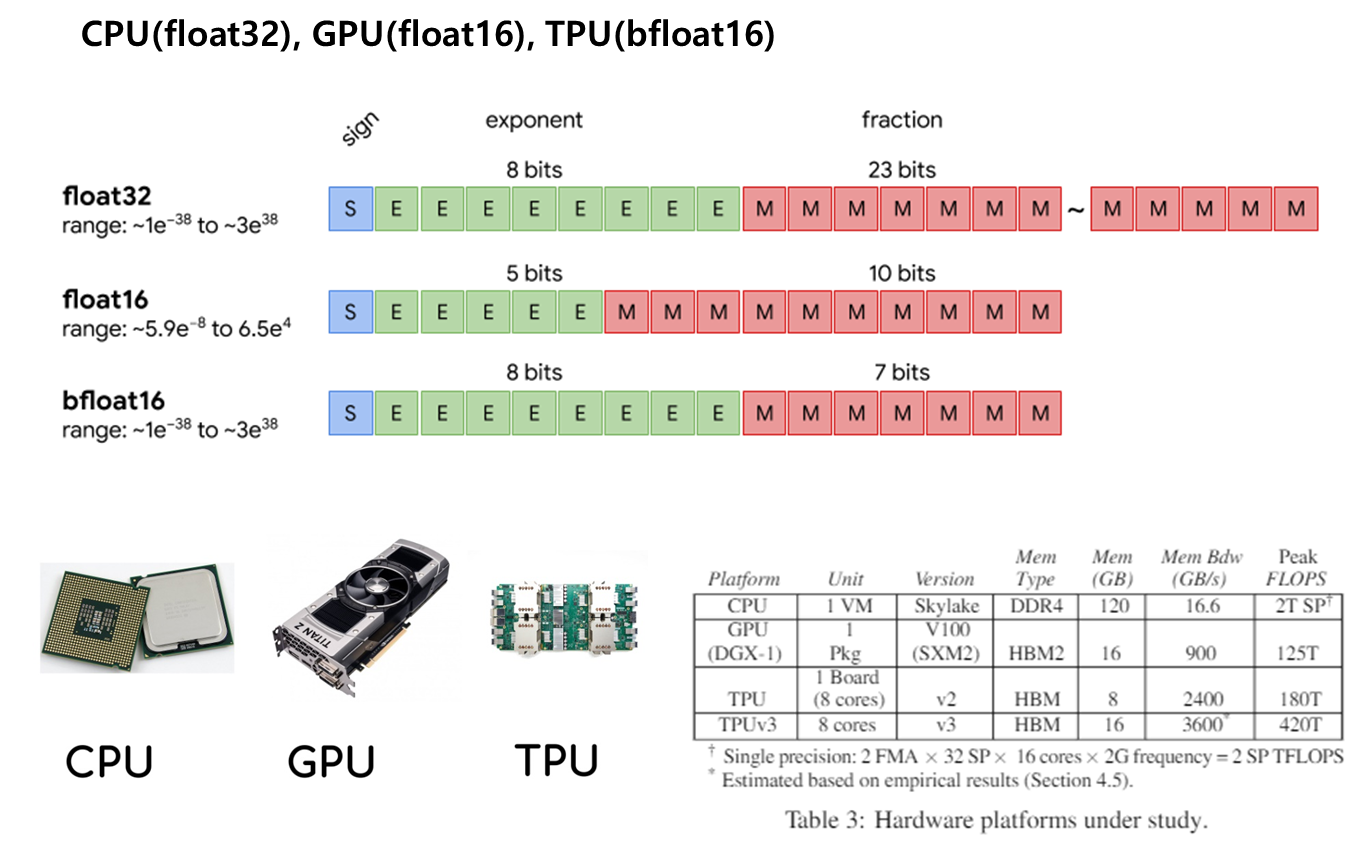

In [ ]:
# prompt: 위 학습 코드에서 실행 시간 출력하기

import time

start_time = time.time()

# Your training code here
history = model.fit(X, y, epochs=300)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Training time: {elapsed_time:.2f} seconds")


plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()


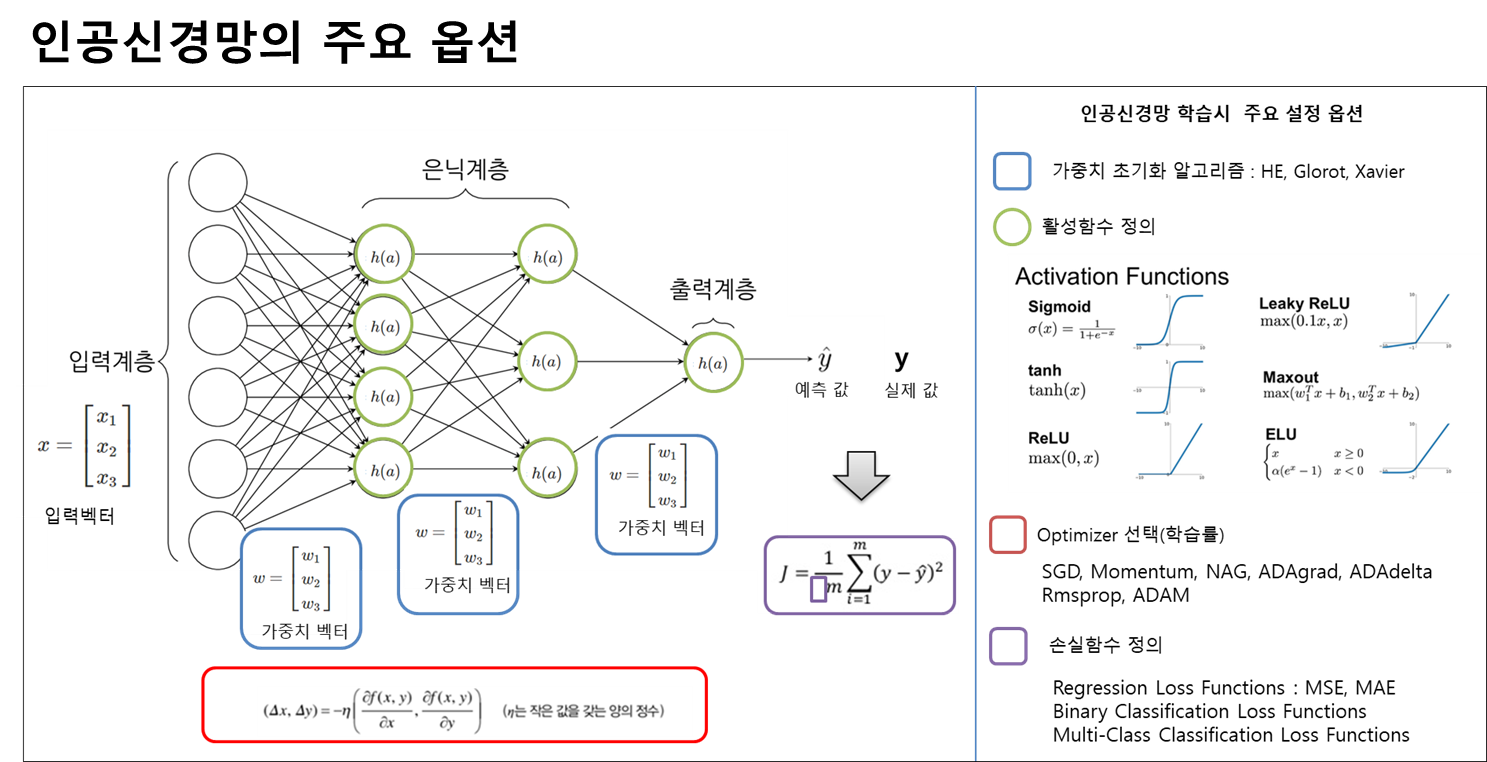

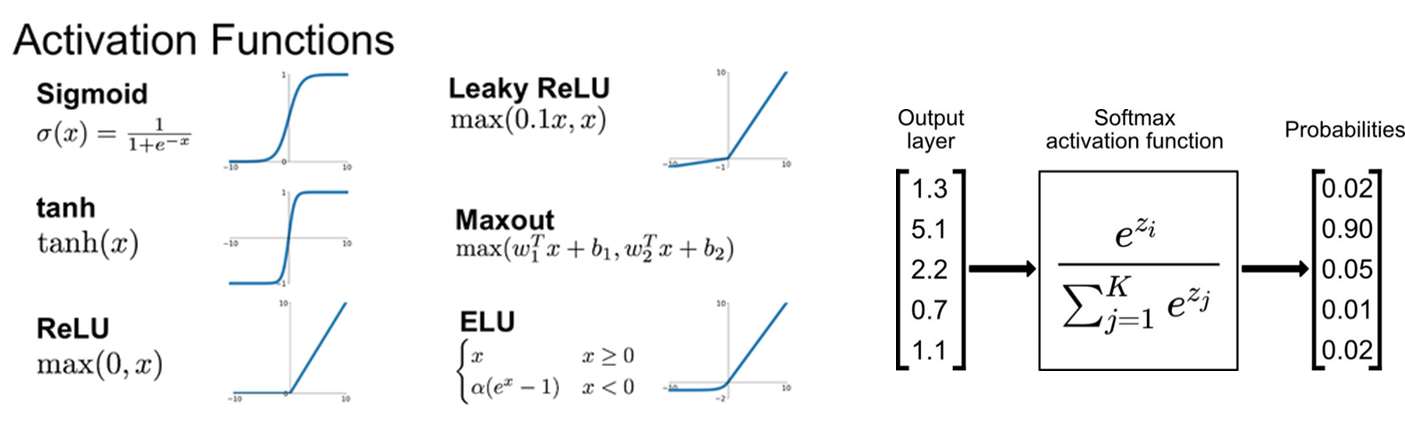

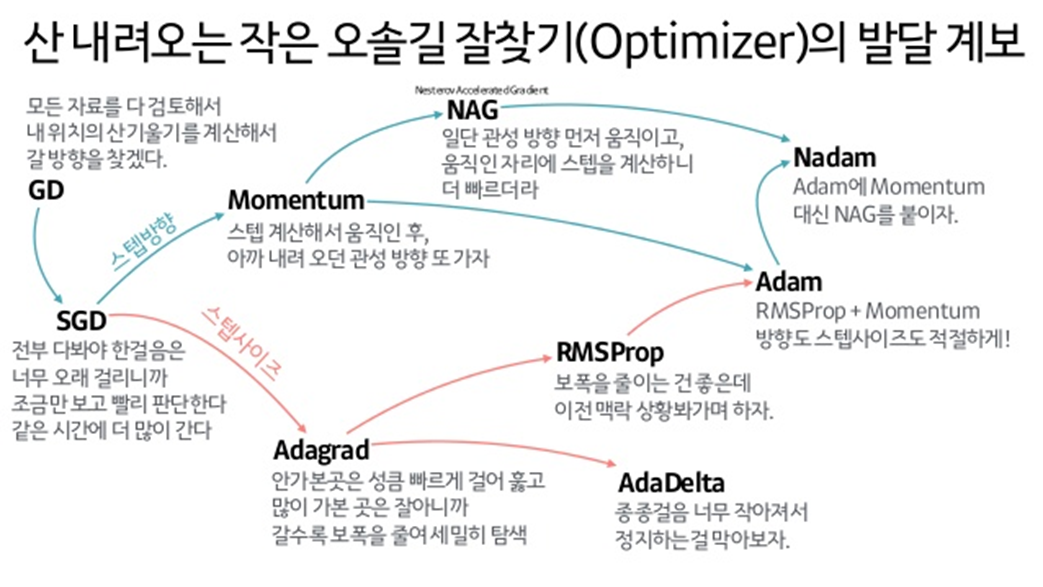

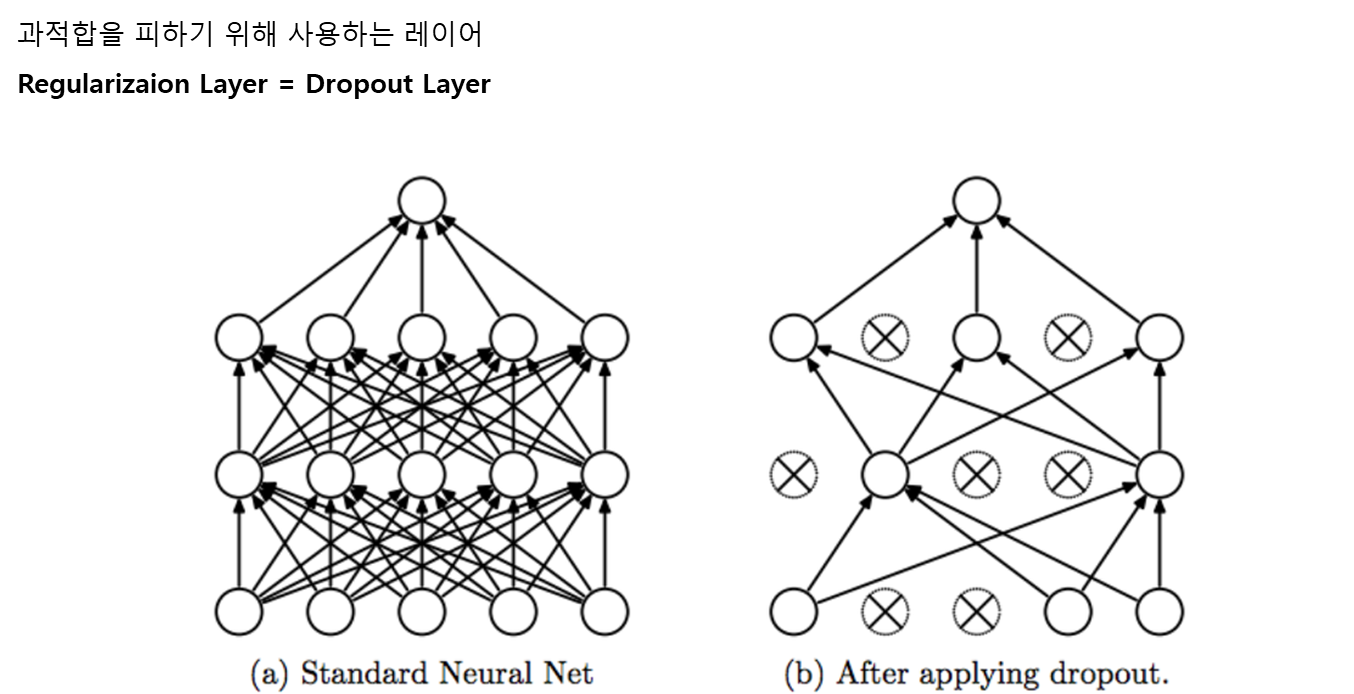